# Decomposition Workflow
# $H \to DLA \to e^{i \rho t} \to BDI \to U_{\text{reconstructed}}$

In [67]:
import numpy as np

## Choose model and decomposition parameters
This cell sets the TFIM model size and evolution time.
You can change n, J, h, t and periodic according to your experiment. We remind that we are working with the Hamiltonian:
$
\begin{equation}
    H = -J \sum^{N-2}_{i=0}Z_iZ_{i+1} -h \sum^{N-1}_{i=0}X_i,
\end{equation}
$

In [68]:
# Model parameters
n = 2
J = 1.0
h = 1.0
t = 0.5
rotated = True
periodic = False

print(f"n = {n}, J = {J}, h = {h}, t = {t}, rotated = {rotated}, periodic = {periodic}")

n = 2, J = 1.0, h = 1.0, t = 0.5, rotated = True, periodic = False


In [69]:
from build_TFIM import TFIM_Ham

if n <= 10:
    hamiltonian = TFIM_Ham(n)
    print(f"Hamiltonian shape: {hamiltonian.shape}")
    print(hamiltonian)

Hamiltonian shape: (4, 4)
[[-2.  0.  0. -1.]
 [ 0.  0. -1.  0.]
 [ 0. -1.  0.  0.]
 [-1.  0.  0.  2.]]


## Build DLA generators (Pauli-word form)
We generate TFIM Pauli words and grow the DLA closure.

In [70]:
from find_DLA import tfim_pauliwords_gen, dla_pauli_words

generators = tfim_pauliwords_gen(n, rotated=rotated, periodic=periodic)
dla_words = dla_pauli_words(generators)

print("Initial generators:", len(generators))
print("DLA size:", len(dla_words))
print("First few DLA words:", dla_words)

Initial generators: 3
DLA size: 6
First few DLA words: [('X', 'X'), ('Z', 'I'), ('I', 'Z'), ('Y', 'X'), ('X', 'Y'), ('Y', 'Y')]


## Map to the Majorana/isomorphic so(2n) matrix
This creates the isomorphism $\rho(iH)$ used before exponentiation.

In [71]:
from build_isomorphism import map_to_majarana, build_so_matrix

maj_mapping = map_to_majarana(generators, J=J, h=h)
print(maj_mapping)
rho_iH = build_so_matrix(maj_mapping, n)

print("rho(iH) shape:", rho_iH.shape)
print("rho(iH) skew Hermitian?", np.allclose(rho_iH.T, -rho_iH, atol=1e-10))
print(rho_iH)

{('X', 'X'): (1.0, (0, 3)), ('Z', 'I'): (-1.0, (0, 1)), ('I', 'Z'): (-1.0, (2, 3))}
rho(iH) shape: (4, 4)
rho(iH) skew Hermitian? True
[[ 0. -2.  0.  2.]
 [ 2.  0.  0.  0.]
 [ 0.  0.  0. -2.]
 [-2.  0.  2.  0.]]


## Exponentiate to get the matrix to decompose
Now build $U(t)=\exp(t\,\rho(iH))$ and verify unitarity/orthogonality.

In [72]:
from BDI_decomp import from_generator

U_t = from_generator(rho_iH, t=t)

print("U(t) shape:", U_t.shape)
print("Is U(t) unitary?", np.allclose(U_t @ U_t.conj().T, np.eye(U_t.shape[0]), atol=1e-10))
print("Is U(t) real (orthogonal case)?", np.allclose(U_t.imag, 0.0, atol=1e-10))

U(t) shape: (4, 4)
Is U(t) unitary? True
Is U(t) real (orthogonal case)? True


## One-step BDI KAK decomposition
Decompose $U(t)$ one step, rebuild $K_1 A K_2$, and check reconstruction error to verify BDI.

In [73]:
from BDI_decomp import bdi, build_kak

k11, k12, theta, k21, k22 = bdi(U_t)
K1, A, K2 = build_kak(k11, k12, theta, k21, k22)
U_rec = K1 @ A @ K2

print("K1 shape:", K1.shape, "A shape:", A.shape, "K2 shape:", K2.shape)
print("One-step reconstruction allclose:", np.allclose(U_t, U_rec, atol=1e-10))
print("Max reconstruction error:", np.max(np.abs(U_t - U_rec)))

K1 shape: (4, 4) A shape: (4, 4) K2 shape: (4, 4)
One-step reconstruction allclose: True
Max reconstruction error: 2.7755575615628914e-16


## Recursive BDI
Run the recursive factorization and print operation counts by type.

In [74]:
from BDI_decomp import recursive_bdi

ops = recursive_bdi(U_t, num_iter=None, return_all=False) # This cell needs return_all=False to get the final list of ops
print("Total recursive ops:", len(ops))

types = {}
for _, _, _, op_type in ops:
    types[op_type] = types.get(op_type, 0) + 1

print("Operation type counts:")
for k in sorted(types, key=lambda x: str(x)):
    print(f" {k}: {types[k]}")

print(ops)


Total recursive ops: 5
Operation type counts:
 a0: 1
 k1: 2
 k2: 2
[(array([[ 0.5109844 ,  0.85958999],
       [-0.85958999,  0.5109844 ]]), 0, 2, 'k1'), (array([[-0.85958999,  0.5109844 ],
       [-0.5109844 , -0.85958999]]), 2, 4, 'k1'), (array([0.08613249, 0.91386751]), 0, 4, 'a0'), (array([[-0.5109844 , -0.85958999],
       [ 0.85958999, -0.5109844 ]]), 0, 2, 'k2'), (array([[-0.85958999,  0.5109844 ],
       [-0.5109844 , -0.85958999]]), 2, 4, 'k2')]


In [75]:
from BDI_verification import verify_bdi_decomposition
verify_bdi_decomposition(U_t, ops)

Max reconstruction error: 2.7755575615628914e-16
Recursive allclose: True


In [76]:
# Print out the determinants of the K1, A, K2 to check if they are in SO(2n) or O(2n)
det_1 = 0
det_m1 = 0
for element in ops:
    if element[3] in ['k1', 'k2']:
        det = np.linalg.det(element[0])
        #print(f"{element[3]} determinant: {det:.4f}")
        if det > 0.5:
            det_1 += 1
        else:
            det_m1 += 1
print(f"Number of K1/K2 with determinant +1: {det_1}")
print(f"Number of K1/K2 with determinant -1: {det_m1}")

Number of K1/K2 with determinant +1: 4
Number of K1/K2 with determinant -1: 0


## Map Back to Pauli Rotations

In [77]:
from map_back import pw_to_majorana, build_majorana_dla_map, map_ops_to_pauli


In [ ]:
mapping = build_majorana_dla_map(dla_words)
print(f"Majorana DLA map size: {len(mapping)}")
print(mapping)


Majorana DLA map size: 6


In [79]:
from collections import Counter

pauli_decomp = map_ops_to_pauli(ops, mapping, time=t)

print(f"Number of Pauli rotations: {len(pauli_decomp)}")
print(f"Expected number:           {n*(2*n-1)}")
print()

print("Pauli rotations:")
print("-" * 45)
print(f"{'#':>2}  {'stage':>5}  {'Pauli':>8}  {'alpha':>12}")
print("-" * 45)

for i, (word, coeff, op_type) in enumerate(pauli_decomp):
    word_str ="".join(word)
    print(f"{i:>2}  {str(op_type):>5}  {word_str:>8}  {coeff:>12.6f}")

Number of Pauli rotations: 6
Expected number:           6

Pauli rotations:
---------------------------------------------
 #  stage     Pauli         alpha
---------------------------------------------
 0     k1        ZI      0.517233
 1     k1        IZ      1.302632
 2     a0        XY      0.086132
 3     a0        YX     -0.913868
 4     k2        ZI     -1.053563
 5     k2        IZ      1.302632


## Verify Reconstruction

In [80]:
import numpy as np
from scipy.linalg import expm

# ---------------------------------------------------------------------
# Pauli matrix utilities
# ---------------------------------------------------------------------

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

PAULI_MATRICES = {
    "I": I2,
    "X": X,
    "Y": Y,
    "Z": Z,
}


def normalize_pauli_word(word):
    """
    Convert a Pauli word to a string.

    Examples:
        ('X', 'Y') -> 'XY'
        ['Z', 'I'] -> 'ZI'
        'XY'       -> 'XY'
    """
    if isinstance(word, (tuple, list)):
        return "".join(word)
    return str(word)


def pauli_word_to_matrix(word):
    """
    Convert a Pauli word such as 'XYI' to its matrix representation.
    """
    word = normalize_pauli_word(word)

    mat = PAULI_MATRICES[word[0]]
    for p in word[1:]:
        mat = np.kron(mat, PAULI_MATRICES[p])

    return mat


def pauli_rotation(word, alpha):
    """
    Return the matrix exp(-i alpha P), where P is a Pauli word.
    """
    P = pauli_word_to_matrix(word)
    return expm(-1j * alpha * P)


# ---------------------------------------------------------------------
# Reconstruction from the Pauli decomposition
# ---------------------------------------------------------------------

def reconstruct_from_pauli_decomp(pauli_decomp, n, time, reverse_order=False):
    """
    Reconstruct the unitary from a Pauli decomposition.

    Each entry of pauli_decomp is assumed to be
        (pauli_word, coeff, stage)

    The actual gate is
        exp(-i alpha P)

    where alpha = coeff*time for a0 gates,
    and alpha = coeff otherwise.
    """
    U = np.eye(2**n, dtype=complex)

    gates = pauli_decomp[::-1] if reverse_order else pauli_decomp

    for word, coeff, op_type in gates:
        if op_type == "a0":
            alpha = coeff * time
        else:
            alpha = coeff

        gate = pauli_rotation(word, alpha)
        U = gate @ U

    return U


def phase_align_error(U_ref, U_test):
    """
    Compare two unitaries up to global phase.

    Returns:
        phase: global phase correction
        error: Frobenius norm after phase alignment
        close: whether matrices are close after phase alignment
    """
    d = U_ref.shape[0]

    phase = np.angle(np.trace(U_test @ U_ref.conj().T) / d)
    U_aligned = np.exp(-1j * phase) * U_test

    error = np.linalg.norm(U_ref - U_aligned)
    close = np.allclose(U_ref, U_aligned, atol=1e-8)

    return phase, error, close


# ---------------------------------------------------------------------
# Verification
# ---------------------------------------------------------------------

def verify_pauli_decomposition(hamiltonian, pauli_decomp, n, t, reverse_order=False):
    """
    Verify that the Pauli decomposition reconstructs exp(-i H t).
    """
    U_ref = expm(-1j * hamiltonian * t)
    U_rec = reconstruct_from_pauli_decomp(
        pauli_decomp,
        n,
        t,
        reverse_order=reverse_order,
    )

    phase, aligned_error, aligned_close = phase_align_error(U_ref, U_rec)

    print("=" * 70)
    print("Verification of Pauli decomposition")
    print("=" * 70)
    print(f"n:                         {n}")
    print(f"t:                         {t}")
    print(f"Number of Pauli rotations: {len(pauli_decomp)}")
    print(f"Expected n(2n-1):          {n * (2*n - 1)}")
    print()
    print(f"Global phase offset:       {phase:.6f} rad")
    print(f"Close up to global phase?  {aligned_close}")
    print(f"Phase-aligned error:       {aligned_error:.3e}")
    print("=" * 70)

    return {
        "U_ref": U_ref,
        "U_rec": U_rec,
        "global_phase": phase,
        "aligned_error": aligned_error,
        "aligned_close": aligned_close,
    }

In [81]:
if n <= 8:
    verification = verify_pauli_decomposition(
        hamiltonian=hamiltonian,
        pauli_decomp=pauli_decomp,
        n=n,
        t=t,
        reverse_order=True,
    )
else:
    print(f"n={n}: full Hilbert-space verification skipped.")

Verification of Pauli decomposition
n:                         2
t:                         0.5
Number of Pauli rotations: 6
Expected n(2n-1):          6

Global phase offset:       -3.141593 rad
Close up to global phase?  True
Phase-aligned error:       3.909e-16


In [84]:
import pennylane as qml
import matplotlib.pyplot as plt


def pauli_word_to_string(word):
    word = normalize_pauli_word(word)
    return "".join(p for p in word if p != "I")


def pauli_word_to_wires(word):
    word = normalize_pauli_word(word)
    return [i for i, p in enumerate(word) if p != "I"]


def effective_coeff(coeff, stage, time):
    """
    Actual coefficient alpha in exp(-i alpha P).

    In this implementation, the a0 coefficients are stored
    time-normalized, so we multiply them by time here.
    """
    if stage == "a0":
        return coeff * time
    return coeff


def make_paulirot_decomp(pauli_decomp):
    """
    Convert (word, coeff, stage) to PennyLane format:
        (coeff, pauli_string, wires, stage)
    """
    return [
        (
            coeff,
            pauli_word_to_string(word),
            pauli_word_to_wires(word),
            stage,
        )
        for word, coeff, stage in pauli_decomp
    ]


paulirot_decomp = make_paulirot_decomp(pauli_decomp)


def kak_circuit(time):
    """
    Apply the Pauli decomposition as a PennyLane circuit.

    Mathematical gate:
        exp(-i alpha P)

    PennyLane convention:
        PauliRot(phi, P) = exp(-i phi P / 2)

    Therefore:
        phi = 2 alpha
    """
    for coeff, pauli_str, wires, stage in paulirot_decomp[::-1]:
        alpha = effective_coeff(coeff, stage, time)
        qml.PauliRot(2 * alpha, pauli_str, wires=wires)


dev = qml.device("default.qubit", wires=n)


@qml.qnode(dev)
def circuit(time):
    kak_circuit(time)
    return qml.state()

Verification of PennyLane circuit
Close up to global phase? True
Phase-aligned error:      1.031e-15
Global phase offset:      3.141593 rad


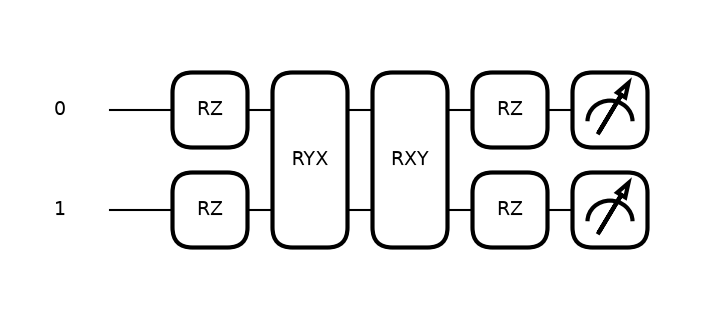

In [ ]:
if n <= 6:
    U_ref = expm(-1j * hamiltonian * t)
    U_circ = qml.matrix(circuit)(t)

    phase, aligned_error, aligned_close = phase_align_error(U_ref, U_circ)

    print("=" * 70)
    print("Verification of PennyLane circuit")
    print("=" * 70)
    print(f"Close up to global phase? {aligned_close}")
    print(f"Phase-aligned error:      {aligned_error:.3e}")
    print(f"Global phase offset:      {phase:.6f} rad")
    qml.draw_mpl(circuit)(t)
    plt.show()